# 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, brentq
import time

from source import compute_bounds, assemble_Gt, discrete_min_kconvex

# 2. Compute labels

## 2.1. Data

Set random seed for reproducibility.

In [2]:
seed = 42
rng = np.random.default_rng(seed=seed)

Cost parameters

In [3]:
K = 100 # fixed ordering cost
c = 0 # proportional ordering cost
b = 10 # penalty cost
h = 1 # inventory holding cost
gamma = 1 # discount factor

Algorithm settings

In [4]:
nsamp = 1_000 # number of demand samples
ninterpol = 1_000 # number of interpolation points
step_init = 5 # initial step size

Demand data (running example of Xiang et al.; see Fig. 1)

In [5]:
demand_type = "continuous"
cv = 0.25 # coefficient of variation
demand_mean = np.array([20, 40, 60, 40])
demand_std = cv * demand_mean

T = len(demand_mean)
demand = demand_mean.reshape(-1, 1) + demand_std.reshape(-1, 1) * rng.normal(size=(T,nsamp)) # shape: (T,N)

## 2.2. Bounds

Compute bounds (low, high) such that low <= s_t <= S_t <= high for all t.

In [6]:
low, high = compute_bounds(D=demand, K=K, b=b, h=h, c=c, gamma=gamma)
low, high

(9, 188)

## 2.3. Labels

In [ ]:
y = np.linspace(low, high, ninterpol).reshape(-1, 1) # grid points for the G_t functions
s_tp1, G_tp1_SK, G_tp1 = 0, 0, 0 # quantities of period t+1 (initial values irrelevant, but must be initialized)

info_dct = {} # store results
for t in reversed(range(T)): # T-1, T-2, ..., 1, 0

    # record computing time
    start = time.time()

    # compute the G_t function
    G = assemble_Gt(t, demand[[t], :], c, b, h, s_tp1, G_tp1_SK, G_tp1, T-1, y, gamma)

    # initial estimates via discrete step-algorithm (Bollapragada & Morton)
    s0, S0, G_min = discrete_min_kconvex(G, high, K, step_init)

    # the result is "exact" for discrete demand and a step size of 1
    if demand_type == "discrete" and step_init==1:
        s = s0
        S = S0
        G_tp1_SK = G_min + K

    # for continuous demand or a large step size, refine initial estimates
    else:
        # refine initial estimate for up-to-order level S
        res = minimize(fun=G, x0=S0, method="Nelder-Mead")
        S = res.x[0].item()
        G_tp1_SK = res.fun + K # G_t(S_t) + K

        # refine initial estimate for reorder point s
        def root_fun(y):
            return G(y)-G_tp1_SK
        s = brentq(f=root_fun, a=s0-step_init, b=S)

        # adjust policy parameters in case of discrete demand
        if demand_type == "discrete":
            S = np.ceil(S) if G(np.ceil(S))<G(np.floor(S)) else np.floor(S)
            G_tp1_SK = G(S) + K
            s = np.ceil(s)
            while G(s) < G_tp1_SK:
                s -= 1
            if G(s) > G_tp1_SK:
                s += 1

    # update s and G for next period
    s_tp1, G_tp1 = s, G # s_t, G_t
    
    # record computing time
    elapsed = time.time() - start

    # store results of period t
    info_dct[t] = (G, s, S, elapsed)

## 2.4 Plot G-functions

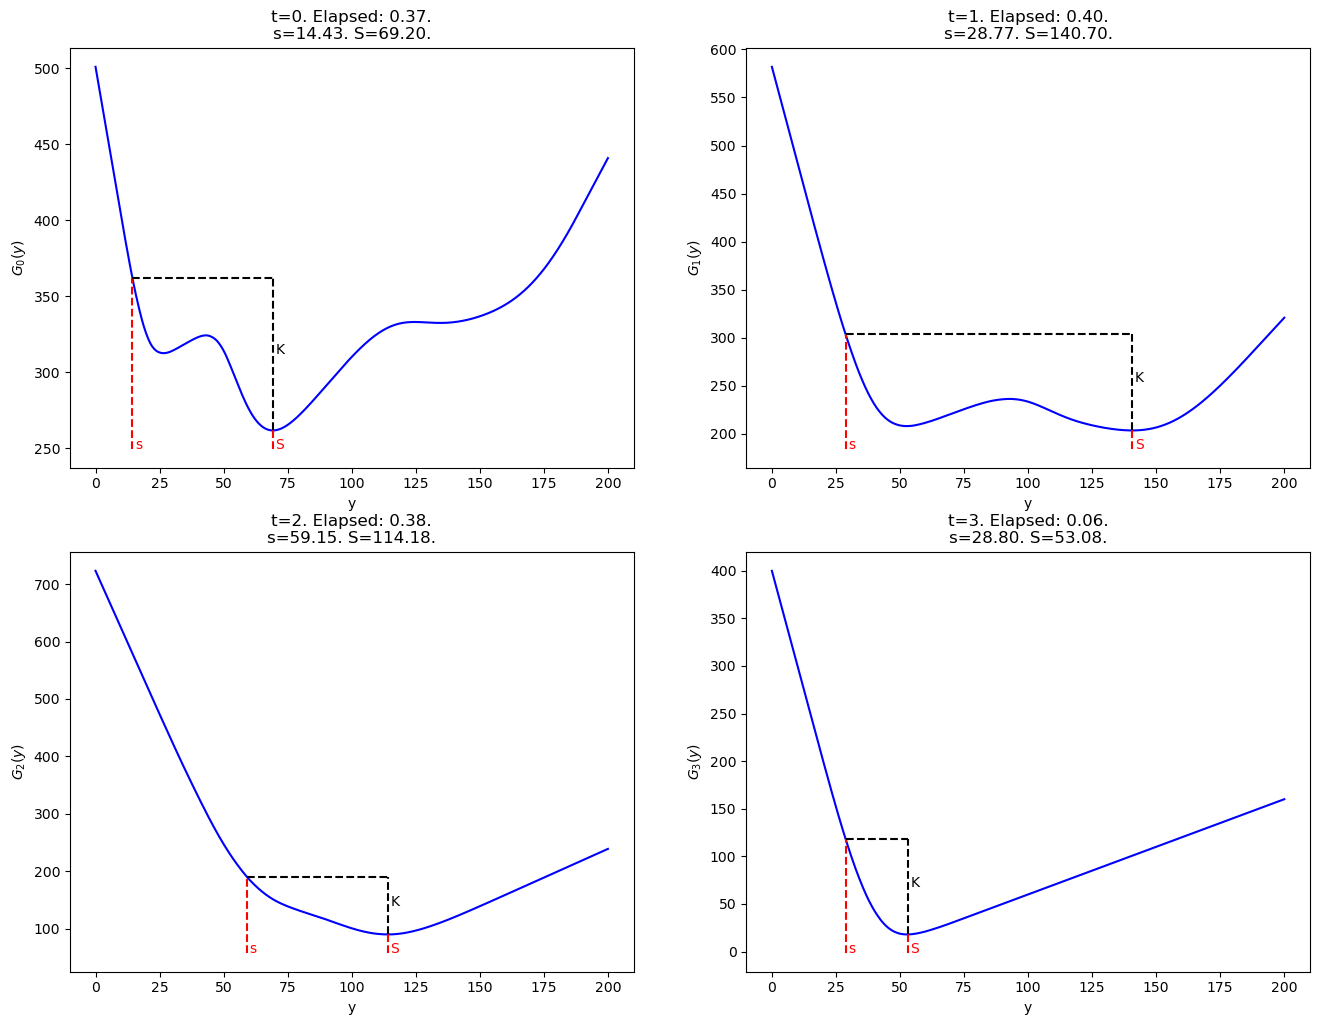

In [8]:
# figure settings
y_plot = np.linspace(0, 200, num=1_000) # grid points to evaluate G functions
ncols = 2 # number of plots per row

# prepare figure
nplots = T
nrows = int(np.ceil(nplots/ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, nrows*6))

for t in range(T):

    G, s, S, elapsed = info_dct[t]

    ax = axes[t//ncols, t%ncols]
    ax.plot(y_plot, G(y_plot), color='b')
    ymin = ax.get_ylim()[0].item()
    for y, text in ((s, "s"), (S, "S")):
        ax.vlines(x=y, ymin=ymin, ymax=G(y), ls='--', color='r')
        ax.annotate(xy=(y+1, ymin), text=text, ha="left", color='r')
    ax.plot(np.linspace(s, S), [G(s)]*50, ls='--', color='k')
    ax.vlines(x=S, ymin=G(S), ymax=G(s), ls='--', color='k')
    ax.annotate(xy=(S+1, G(S)+K/2), text='K', ha='left')

    ax.set_xlabel('y')
    ax.set_ylabel(f'$G_{t}(y)$')
    ax.set_title(f't={t}. Elapsed: {elapsed:.2f}.\ns={s:.2f}. S={S:.2f}.')    